# Case Study 1

This case study explores explicit time-stepping schemes on the Lorenz ‘63
system and asks you to build and validate a reusable numerical solver. The main objective is to develop a
numerical model.

* Develop a numerical model of a chaotic system and verify convergence.
* Explore some properties of Lorenz system.
* Demonstrate the outcome of scientific inquiries about numerical solution of differential equations.

Consider the Lorenz System:

$$\frac{dx}{dt} = \sigma(y-x), \frac{dy}{dt} = x(\rho-z)-y, \frac{dx}{dt} = xy - \beta z$$


The parameters are $(\sigma, \rho, \beta)$ = (10, 28, 8/3)

In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

### Lorenz System 

In [2]:
# Lorenz System 
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    """
    Args:
        t: time
        state: [x, y, z] current state
        sigma, rho, beta: Lorenz parameters
        
    Returns: 
        [dx/dt, dy/dt, dz/dt]
    """
    
    x, y, z = state
    
    dx_dt = sigma*(y - x)
    dy_dt = x*(rho - z)
    dz_dt = x*y - beta*z
    
    return np.array([dx_dt, dy_dt, dz_dt])

### Forward Euler method

$$y_{n+1} = y_n + dt * f(t_n, y_n)$$

In [3]:
# Forward Euler method
def euler(f, y0, t_span, dt):
    """
    Args:
        f: function that dy/dt given (t, y)
        y0: initial condition [array]
        t_span: (t_start, t_end)
        dt: time step
        
    Returns: 
        t: time points (array)
        y: solution values (array)
    """
    
    t_start, t_end = t_span
    t = np.arange(t_start, t_end + dt, dt)
    n_steps = len(t)
    
    # solution array
    y = np.zeros((n_steps, len(y0)))
    y[0] = y0
    
    # Time stepping
    for i in range(n_steps - 1):
        y[i+1] = y[i] + dt * f(t[i], y[i])
        
    return t, y
    

### Runge-Kutta method


In [4]:
# Runge-Kutta method
def rk4(f, y0, t_span, dt):
    """
        Args:
        f: function that dy/dt given (t, y)
        y0: initial condition [array]
        t_span: (t_start, t_end)
        dt: time step
        
    Returns: 
        t: time points (array)
        y: solution values (array)
    """
    
    t_start, t_end = t_span
    t = np.arange(t_start, t_end + dt, dt)
    n_steps = len(t)
    
    # solution array
    y = np.zeros((n_steps, len(y0)))
    y[0] = y0
    
    # Time stepping with RK4
    for i in range(n_steps - 1):
        k1 = f(t[i], y[i])
        k2 = f(t[i] + 0.5*dt, y[i] + 0.5*dt*k1)
        k3 = f(t[i] + 0.5*dt, y[i] + 0.5*dt*k2)
        k4 = f(t[i] + dt, y[i] + dt*k3)
        
        y[i+1] = y[i] + (k1 + 2*k2 + 2*k3 + k4) * (dt/6)
        
    return t, y

### Solving Lorenz system

In [ ]:
y0 = np.array([1., 2., 3.]) # Initial condition

t_span = (0, 100)
dt = 0.02 # time step

t_euler, y_euler = euler(lorenz, y0, t_span, dt)
t_rk4, y_rk4 = rk4(lorenz, y0, t_span, dt)

print(f"Euler: computed {len(t_euler)} time steps")
print(f"RK4: computed {len(t_rk4)} time steps")



Euler: computed 5001 time steps
RK4: computed 5001 time steps


In [6]:
y_euler

array([[ 1.        ,  2.        ,  3.        ],
       [ 1.2       ,  2.5       ,  2.88      ],
       [ 1.46      ,  3.10288   ,  2.7864    ],
       ...,
       [17.4287749 , 13.1611154 , 45.06800215],
       [16.575243  ,  7.21162806, 47.25201773],
       [14.70252001,  0.82949061, 47.12259986]], shape=(5001, 3))

In [7]:
y_rk4

array([[ 1.        ,  2.        ,  3.        ],
       [ 1.23159615,  2.55645343,  2.89355739],
       [ 1.53425432,  3.24871001,  2.82124583],
       ...,
       [ 1.86844763,  3.62646828, 19.76216367],
       [ 2.21893369,  3.98186869, 18.88726947],
       [ 2.57964959,  4.43852114, 18.10302896]], shape=(5001, 3))

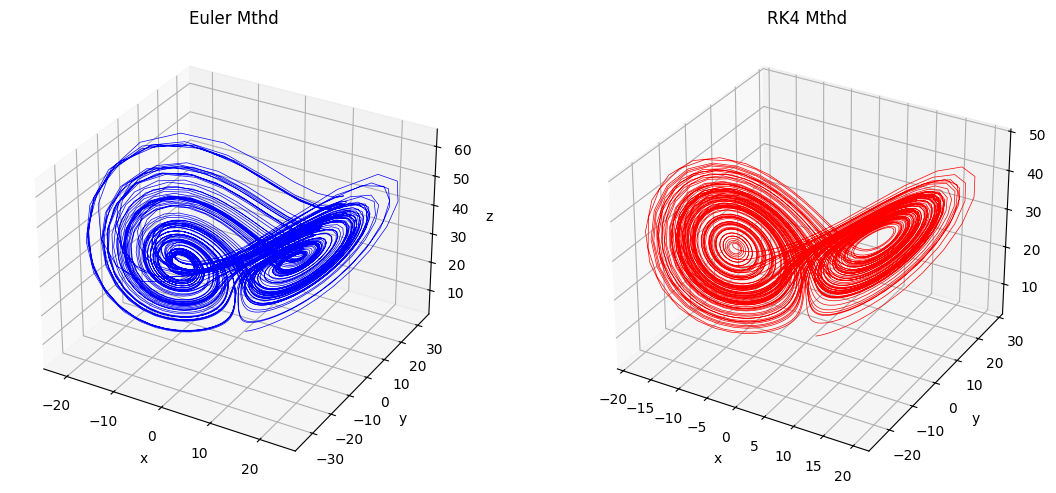

In [8]:
fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(121, projection="3d")
ax1.plot(y_euler[:, 0], y_euler[:, 1], y_euler[:, 2], "b-", linewidth=0.5)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
ax1.set_title("Euler Mthd")

ax1 = fig.add_subplot(122, projection="3d")
ax1.plot(y_rk4[:, 0], y_rk4[:, 1], y_rk4[:, 2], "r-", linewidth=0.5)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
ax1.set_title("RK4 Mthd")

plt.tight_layout()
plt.show()


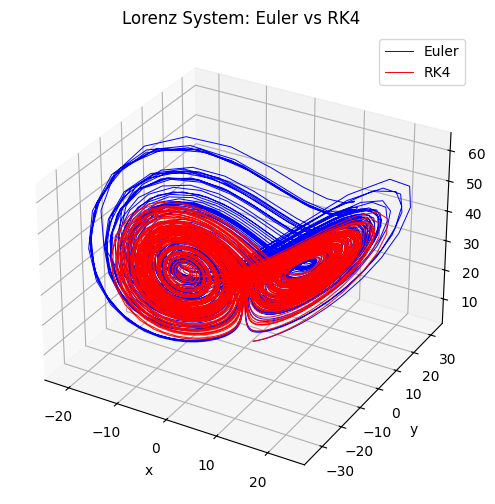

In [9]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(y_euler[:, 0], y_euler[:, 1], y_euler[:, 2], "b-", linewidth=0.7, label="Euler")
ax.plot(y_rk4[:, 0], y_rk4[:, 1], y_rk4[:, 2], "r-", linewidth=0.7, label="RK4")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Lorenz System: Euler vs RK4")
ax.legend()

plt.show()

The plot shows for the given initial conditions and time step, the two methods are very identical to each other. 

### Understanding Convergence

Briefly discuss what you observed regarding convergence as ∆t →0. Using lead error of any of the
method, explain the convergence behaviour that you observed.

In [10]:
def convergence_euler(y0, t_start, t_end, dt_values):
    """
    Perform convergence analysis for Forward Euler method.
    """
    print("\nForward Euler Method")
    print("-"*40)
    
    solutions = {}
    for dt in dt_values:
        t, y = euler(lorenz, y0, (t_start, t_end), dt)
        solutions[dt] = (t, y)
    
    print(f"{'dt':<12} {'Steps':<10} {'Error':<18}")
    print("-"*40)
    
    errors = []
    for i in range(len(dt_values) - 1):
        dt_coarse = dt_values[i]
        dt_fine = dt_values[i + 1]
        
        _, y_coarse = solutions[dt_coarse]
        _, y_fine = solutions[dt_fine]
        
        error = np.linalg.norm(y_coarse[-1] - y_fine[-1])
        errors.append(error)
        
        if i > 0:
            print(f"{dt_coarse:<12.3f} {len(y_coarse):<10} {error:<18.6f}")
        else:
            print(f"{dt_coarse:<12.3f} {len(y_coarse):<10} {error:<18.6f}")
    
    return dt_values, errors, solutions


def convergence_rk4(y0, t_start, t_end, dt_values):
    """
    Perform convergence analysis for 4th-order Runge-Kutta method.
    """
    print("\n4th-order Runge-Kutta Method")
    print("-"*40)
    
    solutions = {}
    for dt in dt_values:
        t, y = rk4(lorenz, y0, (t_start, t_end), dt)
        solutions[dt] = (t, y)
    
    print(f"{'dt':<12} {'Steps':<10} {'Error':<18}")
    print("-"*40)
    
    errors = []
    for i in range(len(dt_values) - 1):
        dt_coarse = dt_values[i]
        dt_fine = dt_values[i + 1]
        
        _, y_coarse = solutions[dt_coarse]
        _, y_fine = solutions[dt_fine]
        
        error = np.linalg.norm(y_coarse[-1] - y_fine[-1])
        errors.append(error)
        
        if i > 0:
            print(f"{dt_coarse:<12.3f} {len(y_coarse):<10} {error:<18.6f}")
        else:
            print(f"{dt_coarse:<12.3f} {len(y_coarse):<10} {error:<18.6f}")
    
    return dt_values, errors, solutions

In [56]:
def convergence_study(method_name, solver, y0, t_start, t_end, dt_values):
    """
    Parameters
    ----------
    method_name : str
        Name of the numerical method (for printing).
    solver : callable
        Function implementing the solver (e.g., euler, rk4).
    y0 : np.ndarray
        Initial condition.
    t_start, t_end : float
        Time interval.
    dt_values : list[float]
        List of time step sizes (each smaller than the last).

    Returns
    -------
    dt_values : list[float]
        The tested time steps.
    errors : list[float]
        List of estimated errors between consecutive refinements.
    solutions : dict
        Dictionary of time histories keyed by dt.
    """
    print(f"\n{method_name}")
    print("-" * 40)
    
    # Compute solutions for each dt
    solutions = {dt: solver(lorenz, y0, (t_start, t_end), dt) for dt in dt_values}
    
    print(f"{'dt':<12} {'Steps':<10} {'Error':<18}")
    print("-" * 40)
    
    # Compute errors
    errors = []
    for i in range(len(dt_values) - 1):
        dt_coarse = dt_values[i]
        dt_fine = dt_values[i + 1]
        
        _, y_coarse = solutions[dt_coarse]
        _, y_fine = solutions[dt_fine]
        
        error = np.linalg.norm(y_coarse[-1] - y_fine[-1])
        errors.append(error)
        
        print(f"{dt_coarse:<12.4f} {len(y_coarse):<10} {error:<18.6f}")
    
    return dt_values, errors, solutions

For the convergence analysis, we use the same time interval of 0 to 100 and initial conditions of `[1, 2, 3]`.

And test at time steps of
* 0.02
* 0.01
* 0.005
* 0.0025

In [57]:
y0 = np.array([1.0, 2.0, 3.0])
t_start, t_end = 0.0, 100.0
dt_values = [0.05, 0.02, 0.01, 0.005, 0.0025, 0.001]

Euler Convergence

In [58]:
dt_val_euler, err_euler, sol_euler = convergence_study("Euler Method", euler, y0, t_start, t_end, dt_values)


Euler Method
----------------------------------------


/var/folders/tl/52w5zxkd1zl65mr95qllj_3h0000gn/T/ipykernel_42280/700677604.py:16: RuntimeWarning: overflow encountered in scalar multiply
  dy_dt = x*(rho - z)
/var/folders/tl/52w5zxkd1zl65mr95qllj_3h0000gn/T/ipykernel_42280/700677604.py:17: RuntimeWarning: overflow encountered in scalar multiply
  dz_dt = x*y - beta*z
/var/folders/tl/52w5zxkd1zl65mr95qllj_3h0000gn/T/ipykernel_42280/700677604.py:17: RuntimeWarning: invalid value encountered in scalar subtract
  dz_dt = x*y - beta*z
/var/folders/tl/52w5zxkd1zl65mr95qllj_3h0000gn/T/ipykernel_42280/3554373316.py:25: RuntimeWarning: invalid value encountered in add
  y[i+1] = y[i] + dt * f(t[i], y[i])


dt           Steps      Error             
----------------------------------------
0.0500       2001       nan               
0.0200       5001       29.043503         
0.0100       10001      8.831416          
0.0050       20001      5.425606          
0.0025       40001      14.017298         


Runge Kutta Convergence

In [59]:
dt_val_rk4, err_rk4, sol_rk4 = convergence_study("RK4 Method", rk4, y0, t_start, t_end, dt_values)


RK4 Method
----------------------------------------
dt           Steps      Error             
----------------------------------------
0.0500       2001       14.511938         
0.0200       5001       13.077318         
0.0100       10001      28.767748         
0.0050       20001      30.359070         
0.0025       40001      14.699618         


### Q3. 
Compare the solutions obtained by two methods. Plot t vs x(t), t vs y(t), and t vs z(t). For each plot,
you will show and compare two curves due to two methods. The time step and initial condition are your
choice, but the submission should state the value of $\Delta t$.

For these plots, I reduce the time span (or time range) to `0 to 10` so we can observe the difference between the two methods. I used an initial condition of `1, 1, 1` and a **time step ($\Delta t$ of 0.01)

<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
/var/folders/tl/52w5zxkd1zl65mr95qllj_3h0000gn/T/ipykernel_42280/4066158923.py:9: SyntaxWarning: invalid escape sequence '\D'
  fig.suptitle('Lorenz System: Euler vs RK4 at $\Delta t = 0.01$', fontsize=16, fontweight='bold')


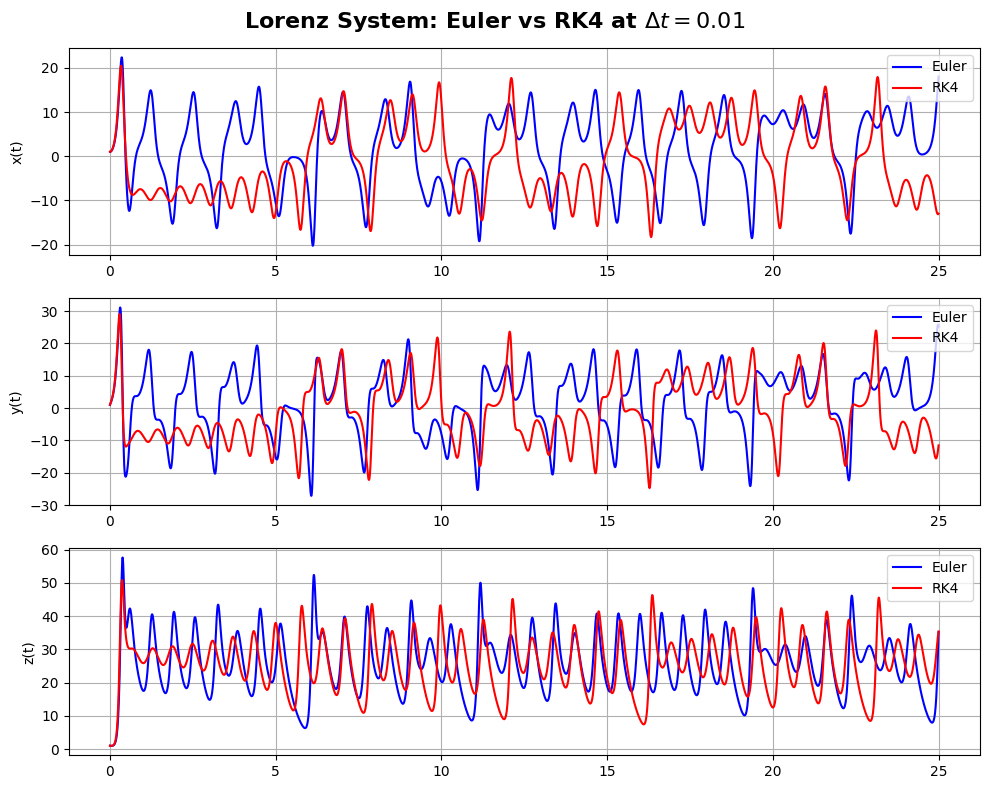

In [65]:
y0 = np.array([1., 1., 1.]) # Initial condition
t_span = (0, 25)
dt = 0.01 # time step

t_euler, y_euler = euler(lorenz, y0, t_span, dt)
t_rk4, y_rk4 = rk4(lorenz, y0, t_span, dt)

fig, axs = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Lorenz System: Euler vs RK4 at $\Delta t = 0.01$', fontsize=16, fontweight='bold')

axs[0].plot(t_euler, y_euler[:, 0], 'b-', label='Euler')
axs[0].plot(t_rk4, y_rk4[:, 0], 'r-', label='RK4')
axs[0].set_ylabel("x(t)")
axs[0].legend(loc='upper right')
axs[0].grid(1)

axs[1].plot(t_euler, y_euler[:, 1], 'b-', label='Euler')
axs[1].plot(t_rk4, y_rk4[:, 1], 'r-', label='RK4')
axs[1].set_ylabel("y(t)")
axs[1].legend(loc='upper right')
axs[1].grid(1)


axs[2].plot(t_euler, y_euler[:, 2], 'b-', label='Euler')
axs[2].plot(t_rk4, y_rk4[:, 2], 'r-', label='RK4')
axs[2].set_ylabel("z(t)")
axs[2].legend(loc='upper right')
axs[2].grid(1)


plt.tight_layout()
plt.show()

### Q5.